In [1]:
# ensure classes imported from .py files are dynamically updated
%load_ext autoreload
%autoreload 2


# plot matplots nicely
%matplotlib inline  

In [2]:
from stericheight.plotting_fns import PlottingFns
from stericheight.data_handler import *
from stericheight.steric_height import *
from functions import Functions
from OceanDataStore import OceanDataCatalog

pfns = PlottingFns()
fns = Functions()


In [3]:
import gsw
import cmocean
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import pickle
import glob

lon = 145
refz=1000
fname_glorys1 = '../data/GLORYS/glorys_001.nc'
fname_glorys2 = '../data/GLORYS/glorys_002.nc'
fname_sose = '../data/SOSE/adelie3d/Jenny_AdelieSlices'
fname_zhou = '../data/CLIM_3D_forJenny.nc'


In [4]:
elevation_ = GEBCO(coarsen_factor=1).ds.elevation

In [5]:
full_extent = [138, 150,-68,-64]
expanded_extent = [132, 156, -68, -62]

elevation = elevation_.sel(latitude = slice(expanded_extent[2], expanded_extent[3]), longitude = slice(expanded_extent[0],expanded_extent[1]))


In [6]:
# GET COLOURS
cdict = pickle.load(open('cdict.pkl','rb'))


In [7]:
def plot_transect(data,ax,title,vmin,vmax):
    im=data.plot.contourf(ax=ax,vmin=vmin,vmax=vmax,cmap=cmocean.cm.balance,add_colorbar=False,levels=40)
    #ax.set_title(title)
    # ax.set_ylim([1000,0])
    ax.set_xlim([-66.5,-64.5])
    ax.invert_yaxis()
    return im


In [8]:
dscli = xr.open_dataset(fname_zhou)
dscli = dscli.squeeze().rename({'lat':'latitude','lon':'longitude','prs':'pressure'}) \
    .swap_dims({'NB_y':'latitude','NB_x':'longitude','NB_LEV':'pressure'})
dscli = fns.crop_to_extent(dscli,full_extent).sel(longitude=lon)
dscli['sigma0'] = gsw.density.sigma0(dscli.sa,dscli.ct)

In [9]:
def plot_clim(ax,var,title,cmap):
    im=ax.contourf(dscli.latitude,dscli.pressure,dscli[var],cmap=cmap,levels=40)
    ax.plot(elevation.latitude,-elevation.sel(longitude=lon,method='nearest'))
    ax.set_ylim([0,1500])
    ax.set_xlim([-67.1,-65])
    ax.set_ylabel('Pressure/dbar')
    ax.set_xlabel('Latitude')
    #ax.set_yscale('log')
    ax.yaxis.set_inverted(True)

    cbar = plt.colorbar(im)
    cbar.set_label(title)


In [10]:
sose=xr.open_mfdataset(glob.glob(fname_sose + '/*.nc'))

idx=sose.SALT.load() > 5
sose = sose.where(idx,np.nan)

# use SOSE data to define time and loc bounds
extent = [sose.XC.min(), sose.XC.max(), sose.YC.min(), sose.YC.max()]

sose['pres'] = gsw.conversions.p_from_z(sose.Z,sose.YC.mean())

sose = sose.swap_dims({'Z':'pres'}).drop_vars('Z')

# make monthly
sose=sose.resample({'time':'MS'}).mean()

#sose = sose.sel(pres=slice(0,1000))
sose['asal'] = gsw.SA_from_SP(sose.SALT,sose.pres,sose.XC,sose.YC)
sose['ctemp'] = gsw.CT_from_pt(sose.asal,sose.THETA)
sose['rho'] = gsw.density.rho(sose.asal,sose.ctemp,sose.pres)




In [11]:
# use SOSE data to define time and loc bounds
extent = [sose.XC.min(), sose.XC.max(), sose.YC.min(), sose.YC.max()]
t1 = sose.time[0]

In [12]:
ds1 = xr.open_dataset(fname_glorys1)
ds2 = xr.open_dataset(fname_glorys2)
glorys = xr.merge([ds1,ds2])

glorys = fns.crop_to_extent(glorys,extent)
# make monthly
glorys = glorys.resample({'time':'MS'}).mean()
glorys['pres'] = gsw.conversions.p_from_z(-glorys.depth,glorys.latitude.mean())

glorys = glorys.swap_dims({'depth':'pres'}).drop_vars('depth')#.sel(pres=slice(0,1000))

glorys['asal'] = gsw.SA_from_SP(glorys.so,glorys.pres,glorys.longitude,glorys.latitude)
glorys['ctemp'] = gsw.CT_from_pt(glorys.asal,glorys.thetao)
glorys['rho'] = gsw.density.rho(glorys.asal,glorys.ctemp,glorys.pres)

t2 = glorys.time[-1]


/tmp/ipykernel_2533878/1240433517.py:3: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'depth' ('depth',) The recommendation is to set join explicitly for this case.
  glorys = xr.merge([ds1,ds2])


In [13]:
catalog = OceanDataCatalog(catalog_name="noc-stac")


In [14]:
# load nemo data
nemo = catalog.open_dataset(id='noc-npd-era5/npd-eorca12-era5v1/r1i1c1f1/T1m_4d',variable_names=['thetao_con','so_abs'])

# prepare nemo
# crop to region
lats = nemo.nav_lat.load()
lons = nemo.nav_lon.load()
mask = (lats >= extent[2]) & (lats <= extent[3]) & (lons >= extent[0]) & (lons <= extent[1])
# crop to area and coarsen
nemo = nemo.where(mask,drop=True).coarsen({'y':6,'x':6},boundary='trim').mean()

# make monthly
nemo = nemo.rename({'time_counter':'time'}).resample({'time':'MS'}).mean()

nemo['pres'] = gsw.conversions.p_from_z(-nemo.deptht,nemo.nav_lat.mean())

nemo = nemo.swap_dims({'deptht':'pres'}).drop_vars('deptht')#.sel(pres=slice(0,1000))

nemo['rho'] = gsw.density.rho(nemo.so_abs,nemo.thetao_con,nemo.pres)



In [15]:
# assign colours for easy plotting
colors = {'SHA': 'rebeccapurple',
          'GPHA': 'lightsteelblue',
          'GLORYS': 'lightseagreen',
          'NEMO' : 'palevioletred',
          'SOSE' : 'orange',
          'EN4': 'dodgerblue',
          'MASS': 'grey'}


In [16]:
glorys['sigma0'] = gsw.density.sigma0(glorys.asal,glorys.ctemp)
gloryslon = glorys.sel(longitude=lon,method='nearest').mean('time')


In [17]:
sose['sigma0'] = gsw.density.sigma0(sose.asal,sose.ctemp)
nemo['sigma0'] = gsw.density.sigma0(nemo.so_abs,nemo.thetao_con)


soselon = sose.sel(XC=lon,method='nearest').mean('time')
nemolon = nemo.where((nemo.nav_lon >= lon-0.2) & (nemo.nav_lon <= lon+0.2),drop=True).squeeze().mean('time')

In [19]:
nemolon_sigma=xr.open_dataarray('nemolon_sigma0.nc')

In [34]:
def plot_clim(ax,da,lat,pres,title,cmap,figtitle=None):
    im=ax.contourf(lat,pres,da,cmap=cmap,levels=40,vmin=27.2,vmax=27.9)
    ax.plot(elevation.latitude,-elevation.sel(longitude=lon,method='nearest'))
    ax.set_ylim([0,500])
    ax.set_xlim([-66.5,-65.5])
    ax.set_ylabel('Pressure/dbar')
    ax.set_xlabel('Latitude')
    #ax.set_yscale('log')
    ax.yaxis.set_inverted(True)
    ax.set_title(figtitle,loc='left')

    cbar = plt.colorbar(im)
    cbar.set_label('σ ('+title+')')


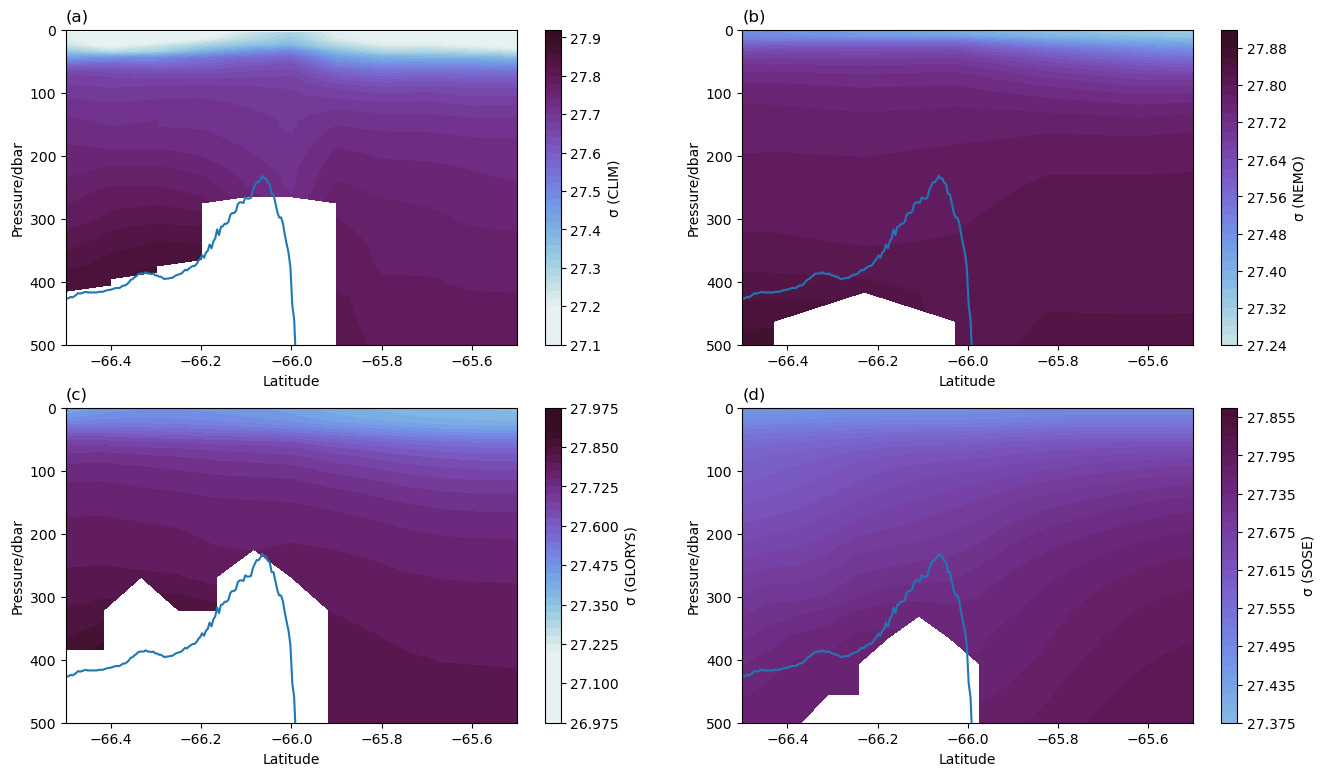

In [35]:
fig,ax = plt.subplots(2,2,figsize=(16,9))
plot_clim(ax[0][0],dscli.sigma0,dscli.latitude,dscli.pressure,'CLIM',cmocean.cm.dense,'(a)')
plot_clim(ax[1][1],soselon.sigma0,soselon.YC,soselon.pres,'SOSE',cmocean.cm.dense,'(d)')
plot_clim(ax[0][1],nemolon_sigma,nemolon.nav_lat,nemolon.pres,'NEMO',cmocean.cm.dense,'(b)')
plot_clim(ax[1][0],gloryslon.sigma0,gloryslon.latitude,gloryslon.pres,'GLORYS',cmocean.cm.dense,'(c)')


<xarray.Dataset> Size: 54kB
Dimensions:     (pres: 75, nav_lat: 29)
Coordinates:
  * pres        (pres) float64 600B 0.5108 1.571 2.694 ... 5.833e+03 6.044e+03
  * nav_lat     (nav_lat) float64 232B -68.88 -68.7 -68.52 ... -63.47 -63.25
    nav_lon     (nav_lat) float64 232B 144.9 144.9 144.9 ... 144.9 144.9 144.9
    y           (nav_lat) float64 232B 885.5 891.5 897.5 ... 1.048e+03 1.054e+03
    x           float64 8B 862.5
Data variables:
    thetao_con  (pres, nav_lat) float32 9kB dask.array<chunksize=(25, 29), meta=np.ndarray>
    so_abs      (pres, nav_lat) float32 9kB dask.array<chunksize=(25, 29), meta=np.ndarray>
    rho         (pres, nav_lat) float64 17kB dask.array<chunksize=(25, 29), meta=np.ndarray>
    sigma0      (pres, nav_lat) float64 17kB nan nan nan nan ... nan nan nan nan
Attributes:
    name:         OUTPUT/eORCA12_1m_grid_T
    description:  ocean T grid variables
    title:        ocean T grid variables
    Conventions:  CF-1.6
    timeStamp:    2025-Dec-03 20:51:31 GMT
    uuid:         a8ac37d1-a8ff-4925-b791-f0d6111ec8e1

In [71]:
sosecli = soselon.interp({'YC':dscli.latitude,'pres':dscli.pressure})
nemocli = nemolon.swap_dims({'y':'nav_lat'}).interp({'nav_lat':dscli.latitude,'pres':dscli.pressure})
gloryscli = gloryslon.interp({'latitude':dscli.latitude,'pres':dscli.pressure})

In [75]:
def plot_clim(ax,da,lat,pres,title,cmap):
    im=ax.contourf(lat,pres,da,cmap=cmap,levels=40,vmin=-0.4,vmax=0.4)
    ax.plot(elevation.latitude,-elevation.sel(longitude=lon,method='nearest'))
    ax.set_ylim([0,1500])
    ax.set_xlim([-67.1,-65])
    ax.set_ylabel('Pressure/dbar')
    ax.set_xlabel('Latitude')
    #ax.set_yscale('log')
    ax.yaxis.set_inverted(True)

    cbar = plt.colorbar(im)
    cbar.set_label(title)


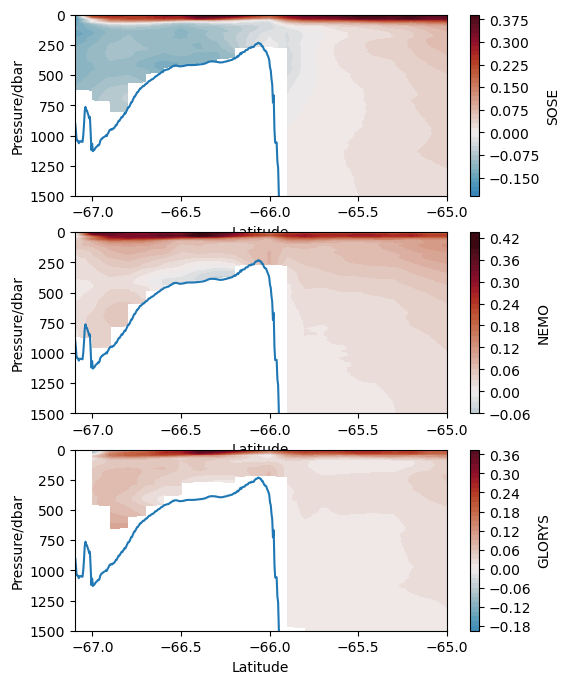

In [76]:
fig,ax = plt.subplots(3,1,figsize=(6,8))
plot_clim(ax[0],sosecli.sigma0-dscli.sigma0,dscli.latitude,dscli.pressure,'SOSE',cmocean.cm.balance)
plot_clim(ax[1],nemocli.sigma0-dscli.sigma0,dscli.latitude,dscli.pressure,'NEMO',cmocean.cm.balance)
plot_clim(ax[2],gloryscli.sigma0-dscli.sigma0,dscli.latitude,dscli.pressure,'GLORYS',cmocean.cm.balance)



In [84]:
def plot_clim(ax,da,lat,pres,title,cmap):
    im=ax.contourf(lat,pres,da,cmap=cmap,levels=40,vmin=27.6,vmax=27.8)
    ax.plot(elevation.latitude,-elevation.sel(longitude=lon,method='nearest'))
    ax.set_ylim([150,550])
    ax.set_xlim([-66.3,-65.8])
    ax.set_ylabel('Pressure/dbar')
    ax.set_xlabel('Latitude')
    #ax.set_yscale('log')
    ax.yaxis.set_inverted(True)

    cbar = plt.colorbar(im)
    cbar.set_label(title)


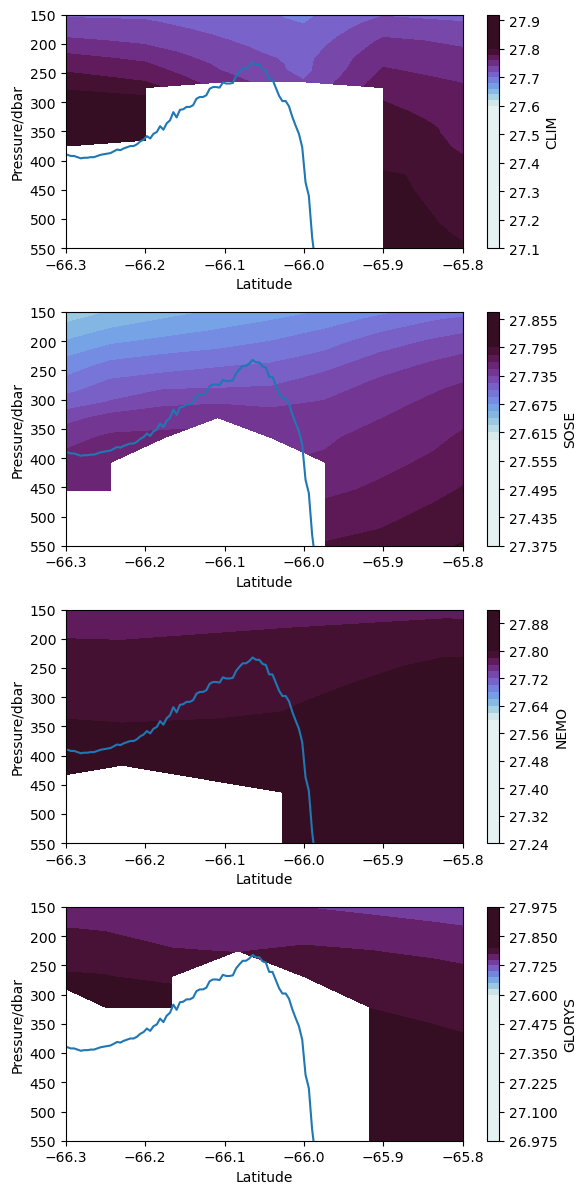

In [85]:
fig,ax = plt.subplots(4,1,figsize=(6,12))
plot_clim(ax[0],dscli.sigma0,dscli.latitude,dscli.pressure,'CLIM',cmocean.cm.dense)
plot_clim(ax[1],soselon.sigma0,soselon.YC,soselon.pres,'SOSE',cmocean.cm.dense)
plot_clim(ax[2],nemolon.sigma0,nemolon.nav_lat,nemolon.pres,'NEMO',cmocean.cm.dense)
plot_clim(ax[3],gloryslon.sigma0,gloryslon.latitude,gloryslon.pres,'GLORYS',cmocean.cm.dense)

plt.tight_layout()
